# Phase 1-6: Prediction-Horizon and Autoregressive Rollout Evaluation

Loads the six trained multi-rate models from `multirate/` and performs:

1. In-window horizon (teacher-forced): how does accuracy decay across the
   model's own $K=20$ lead steps? 
2. Autoregressive rollout (closed-loop): how does accuracy decay when the
   model's own outputs are fed back as history, far beyond $K$? This is the
   regime that matters for using the surrogate as an FMU replacement.
3. Speedup: inference cost per prediction and per rolled-out horizon,
   against the FMU reference.


In [ ]:
#  Imports, paths, run discovery
import json, os, sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath("../../"))          # repo root (has fmu2ml/)
import fmu2ml.surrogate as surrogate
from fmu2ml.surrogate.data import store as _store
from fmu2ml.surrogate.data.normalizer import FederatedNormalizer

warnings.filterwarnings("ignore", category=UserWarning)

# Runs directory: this notebook sits next to it.
RUNS_DIR = Path(os.environ.get("RUNS_DIR", "./runs"))

# The chunk store. config.json does not record the data path, so it must be
# supplied. Default matches phase_common.py / run_phases_sequential.sh.
DATA_DIR = Path(os.environ.get(
    "PHASE_DATA_DIR",
    os.path.expandvars("../../../summit/data/systematic-720")))
STORE_DIR = Path(os.environ.get("PHASE_STORE_DIR", DATA_DIR / "store"))

OUT_DIR = Path(os.environ.get("OUT_DIR", "./horizon_eval"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# phase id -> (run directory name, registry arch name, display label)
PHASES = {
    "1": ("phase1_lstm_mr",             "lstm",            "P1 LSTM"),
    "2": ("phase2_deeponet_mr",         "deeponet",        "P2 DeepONet"),
    "3": ("phase3_hybrid_deeponet_mr",  "hybrid_deeponet", "P3 Hybrid"),
    "4": ("phase4_domain_deeponet_mr",  "domain_deeponet", "P4 Domain"),
    "5": ("phase5_federated_mr",        "federated",       "P5 Grouped. Mul."),
    # "6": ("phase6_federated_pi_mr",     "federated_pi",    "P6 Fed+PI"),
}
SELECT = os.environ.get("PHASES", "1 2 3 4 5").split()

ALL_HEADS = ["G_T", "G_V", "G_p", "G_Vs", "G_ps", "G_W"]
PRED_KEY  = {"G_T": "pred_T", "G_V": "pred_V", "G_p": "pred_p",
             "G_Vs": "pred_Vs", "G_ps": "pred_ps", "G_W": "pred_W"}
IDX_KEY   = {"G_T": "temp_indices",     "G_V": "flow_indices",
             "G_p": "pressure_indices", "G_Vs": "flow_sec_indices",
             "G_ps": "pressure_sec_indices", "G_W": "power_indices"}
GCOLOR    = {"G_T": "steelblue", "G_V": "coral", "G_p": "green",
             "G_Vs": "mediumpurple", "G_ps": "goldenrod", "G_W": "teal"}
GUNIT     = {"G_T": "°C", "G_V": "GPM", "G_Vs": "GPM",
             "G_p": "psig", "G_ps": "psig", "G_W": "kW"}

print(f"device      : {DEVICE}")
print(f"runs dir    : {RUNS_DIR.resolve()}")
print(f"store dir   : {STORE_DIR}")
print(f"phases      : {SELECT}")
if not RUNS_DIR.is_dir():
    raise SystemExit(f"RUNS_DIR not found: {RUNS_DIR.resolve()}  (set RUNS_DIR=...)")
if not (STORE_DIR / "store_manifest.json").is_file():
    raise SystemExit(
        f"No store_manifest.json under {STORE_DIR}.\\n"
        "This notebook needs the chunk store the runs trained on. Set "
        "PHASE_DATA_DIR (and optionally PHASE_STORE_DIR) to the dataset that "
        "produced these runs, or run this on the cluster where it lives.")

## 1: Reconstruct each run's config, normalizer and model

`config.json` holds only the JSON-safe fields of the dataclass, so the config is
rebuilt by instantiating the phase's own config class with the intersection of
the saved keys and that class's `__dataclass_fields__`. Anything derived
(`multi_rate`, `store_rates`, `physics_K` defaults) is recomputed by
`__post_init__`, which is what we want: it guarantees the reconstructed config
is self-consistent rather than a bag of attributes.

In [ ]:
# config / column_info / normalizer / model loaders
CONFIG_CLASS = {
    "lstm":            surrogate.Phase1Config,
    "deeponet":        surrogate.Phase2Config,
    "hybrid_deeponet": surrogate.Phase3Config,
    "domain_deeponet": surrogate.Phase4Config,
    "federated":       surrogate.Phase5Config,
    "federated_pi":    surrogate.Phase6Config,
}

def load_config(run_dir: Path, arch: str):
    """Rebuild the phase config dataclass from the run's saved config.json."""
    raw = json.loads((run_dir / "config.json").read_text())
    cls = CONFIG_CLASS[arch]
    fields = set(cls.__dataclass_fields__)          # skips properties like multi_rate
    kw = {k: v for k, v in raw.items() if k in fields}
    cfg = cls(kw)
    assert cfg.multi_rate, f"{run_dir.name}: reconstructed config is not multi-rate"
    return cfg

# column_info is derived from the STORE MANIFEST rather than the raw parquet
# schema: the manifest records the exact column order the arrays were written
# with (input_cols then dynamic_cols), so this cannot drift from the arrays.
MANIFEST = _store.load_store_manifest(str(STORE_DIR))
STORE_INPUT_COLS   = list(MANIFEST["input_cols"])
STORE_DYNAMIC_COLS = list(MANIFEST["dynamic_cols"])
STORE_N_INPUT      = int(MANIFEST["n_input"])
assert STORE_N_INPUT == len(STORE_INPUT_COLS)
SCHEMA_DF = pd.DataFrame(columns=STORE_INPUT_COLS + STORE_DYNAMIC_COLS)

def load_column_info(cfg):
    ci = surrogate.build_federated_column_info(SCHEMA_DF, cfg)
    # The store's dynamic column ORDER is what the arrays use; assert the
    # column_info agrees, otherwise every index lookup below is silently wrong.
    assert list(ci["dynamic_cols"]) == STORE_DYNAMIC_COLS, (
        "dynamic column order differs between column_info and the store manifest")
    assert list(ci["input_cols"]) == STORE_INPUT_COLS, (
        "input column order differs between column_info and the store manifest")
    return ci

def load_model(run_dir: Path, arch: str, cfg, column_info):
    model = surrogate.get_architecture(arch)(cfg, column_info=column_info)
    ck = torch.load(run_dir / "model.pt", map_location="cpu", weights_only=False)
    sd = ck["model_state_dict"] if "model_state_dict" in ck else ck
    # DDP checkpoints may carry a "module." prefix.
    if any(k.startswith("module.") for k in sd):
        sd = {k[len("module."):] if k.startswith("module.") else k: v
              for k, v in sd.items()}
    missing, unexpected = model.load_state_dict(sd, strict=False)
    if missing or unexpected:
        print(f"  [warn] {run_dir.name}: missing={len(missing)} unexpected={len(unexpected)}")
        if missing:    print(f"         missing[:4]   = {list(missing)[:4]}")
        if unexpected: print(f"         unexpected[:4]= {list(unexpected)[:4]}")
    return model.to(DEVICE).eval()

RUNS = {}
for pid in SELECT:
    dname, arch, label = PHASES[pid]
    rd = RUNS_DIR / dname
    if not rd.is_dir():
        print(f"skip phase {pid}: {rd} not found"); continue
    cfg  = load_config(rd, arch)
    ci   = load_column_info(cfg)
    nrm  = FederatedNormalizer.load(rd / "normalizer.json")
    mdl  = load_model(rd, arch, cfg, ci)
    man  = json.loads((rd / "data_manifest.json").read_text())
    npar = sum(p.numel() for p in mdl.parameters() if p.requires_grad)
    RUNS[pid] = dict(label=label, arch=arch, dir=rd, config=cfg, column_info=ci,
                     normalizer=nrm, model=mdl, manifest=man, n_params=npar)
    print(f"phase {pid}  {label:<14} {type(mdl).__name__:<28} "
          f"{npar:>12,} params  test_chunks={man['test_chunks']}")

assert RUNS, "no runs loaded"


COLUMN IDENTIFICATION (Federated)
Input columns:              515
Total dynamic outputs:      2827
  G_T  (temperatures):      1028
  G_V  (prim flow):         257
  G_p  (prim pressure):     514
  G_Vs (sec flow):          257
  G_ps (sec pressure):      514
  G_W  (pump power):        257
  Per-type index maps:      11 types
FederatedNormalizer loaded from runs/phase1_lstm_mr/normalizer.json
phase 1  P1 LSTM        MultiRateLSTM                  20,785,886 params  test_chunks=[8, 12, 13, 14, 36, 53, 65, 66, 77, 97, 107, 109, 113]

COLUMN IDENTIFICATION (Federated)
Input columns:              515
Total dynamic outputs:      2827
  G_T  (temperatures):      1028
  G_V  (prim flow):         257
  G_p  (prim pressure):     514
  G_Vs (sec flow):          257
  G_ps (sec pressure):      514
  G_W  (pump power):        257
  Per-type index maps:      11 types
FederatedNormalizer loaded from runs/phase2_deeponet_mr/normalizer.json
phase 2  P2 DeepONet    MultiRateDeepONet              55,5

## 2: Verify the runs share one task

Everything downstream (a common lead grid, a single rollout stride, comparable
metrics) depends on the six runs agreeing on rates, look-backs, horizons and
test chunks. Assert it rather than assume it.

In [3]:
#  task-spec agreement across the loaded runs
def task_signature(r):
    c = r["config"]
    return dict(
        rates      =tuple(c.head_subsample[h]        for h in ALL_HEADS),
        history    =tuple(c.head_history_steps[h]    for h in ALL_HEADS),
        horizon    =tuple(c.head_prediction_steps[h] for h in ALL_HEADS),
        branches   =tuple(c.encoder_groups[h]        for h in ALL_HEADS),
        test_chunks=tuple(r["manifest"]["test_chunks"]),
    )

sigs = {pid: task_signature(r) for pid, r in RUNS.items()}
ref_pid = next(iter(sigs)); ref = sigs[ref_pid]
rows = []
for pid, s in sigs.items():
    diff = [k for k in ref if s[k] != ref[k]]
    rows.append({"phase": pid, "model": RUNS[pid]["label"],
                 "agrees": "yes" if not diff else "NO: " + ",".join(diff)})
print(pd.DataFrame(rows).to_string(index=False)); print()

TASK_OK = all(s == ref for s in sigs.values())
if not TASK_OK:
    print("!! Runs do NOT share a task. Cross-model comparison below is invalid.")
    print("   Re-run the disagreeing phases before using any comparative plot.")

CFG        = RUNS[ref_pid]["config"]
COLUMN_INFO= RUNS[ref_pid]["column_info"]
DYN        = list(COLUMN_INFO["dynamic_cols"]); N_DYN = len(DYN)
N_IN       = len(COLUMN_INFO["input_cols"])
GCOLS      = {h: np.asarray(COLUMN_INFO[IDX_KEY[h]], dtype=np.int64) for h in ALL_HEADS}
TEST_CHUNKS= list(RUNS[ref_pid]["manifest"]["test_chunks"])

RATE = {h: int(CFG.head_subsample[h])        for h in ALL_HEADS}
HIST = {h: int(CFG.head_history_steps[h])    for h in ALL_HEADS}
KMAX = {h: int(CFG.head_prediction_steps[h]) for h in ALL_HEADS}

BRANCH_SPEC = {}
for h in ALL_HEADS:
    b = CFG.encoder_groups[h]
    spec = (RATE[h], HIST[h])
    assert BRANCH_SPEC.setdefault(b, spec) == spec, f"branch {b} has mixed (rate,history)"
RATES = sorted({r for r, _ in BRANCH_SPEC.values()})

print("task specification")
print(f"{'head':6}{'rate':>6}{'look-back':>12}{'horizon':>10}{'branch':>9}{'n_out':>8}")
for h in ALL_HEADS:
    print(f"{h:6}{RATE[h]:>5}s{HIST[h]*RATE[h]:>11}s{KMAX[h]*RATE[h]:>9}s"
          f"{CFG.encoder_groups[h]:>9}{len(GCOLS[h]):>8}")
print(f"\nbranches={BRANCH_SPEC}  rates={RATES}  test chunks={TEST_CHUNKS}")

phase        model agrees
    1      P1 LSTM    yes
    2  P2 DeepONet    yes
    3    P3 Hybrid    yes
    4    P4 Domain    yes
    5 P5 Federated    yes

task specification
head    rate   look-back   horizon   branch   n_out
G_T      30s       1200s      600s     slow    1028
G_V       3s        300s       60s     fast     257
G_p       3s        300s       60s     fast     514
G_Vs      3s        300s       60s     fast     257
G_ps      3s        300s       60s     fast     514
G_W      30s       1200s      600s     slow     257

branches={'slow': (30, 40), 'fast': (3, 100)}  rates=[3, 30]  test chunks=[8, 12, 13, 14, 36, 53, 65, 66, 77, 97, 107, 109, 113]


In [4]:
# memory-map the test-chunk arrays (one per rate); no data enters RAM
TEST_ARRAYS = {}
for cid in TEST_CHUNKS:
    TEST_ARRAYS[cid] = {r: _store.open_chunk_array(str(STORE_DIR), cid, r) for r in RATES}

print(f"{'chunk':>7}" + "".join(f"{'rate'+str(r):>22}" for r in RATES))
for cid, arrs in TEST_ARRAYS.items():
    print(f"{cid:>7}" + "".join(f"{str(arrs[r].shape):>22}" for r in RATES))

# store layout is input_cols then dynamic_cols
for cid, arrs in TEST_ARRAYS.items():
    for r, a in arrs.items():
        assert a.shape[1] == N_IN + N_DYN, (
            f"chunk_{cid} rate{r}: {a.shape[1]} cols, expected {N_IN + N_DYN}")

BASE_RATE = min(RATES)
STRIDE_S  = int(np.lcm.reduce(np.array(RATES, dtype=np.int64)))   # 30 s
K_TAKE    = {h: STRIDE_S // RATE[h] for h in ALL_HEADS}           # steps consumed / stride
for h in ALL_HEADS:
    assert K_TAKE[h] <= KMAX[h], (
        f"{h}: a {STRIDE_S}s stride needs {K_TAKE[h]} steps but the model only "
        f"predicts {KMAX[h]}; rollout stride cannot exceed the model horizon")
print(f"\nrollout stride = {STRIDE_S}s   steps consumed per stride = {K_TAKE}")

  chunk                 rate3                rate30
      8          (6766, 3342)           (676, 3342)
     12          (6766, 3342)           (676, 3342)
     13          (6766, 3342)           (676, 3342)
     14          (6766, 3342)           (676, 3342)
     36          (6766, 3342)           (676, 3342)
     53          (6766, 3342)           (676, 3342)
     65          (6766, 3342)           (676, 3342)
     66          (6766, 3342)           (676, 3342)
     77          (6766, 3342)           (676, 3342)
     97          (6766, 3342)           (676, 3342)
    107          (6766, 3342)           (676, 3342)
    109          (6766, 3342)           (676, 3342)
    113          (6766, 3342)           (676, 3342)

rollout stride = 30s   steps consumed per stride = {'G_T': 1, 'G_V': 10, 'G_p': 10, 'G_Vs': 10, 'G_ps': 10, 'G_W': 1}


In [5]:
#  normalisation helpers, bound to one run's saved statistics
def make_norm(run):
    nrm, ci = run["normalizer"], run["column_info"]
    in_cols, dyn_cols = list(ci["input_cols"]), list(ci["dynamic_cols"])

    def norm_in(x):                       # (B,H,N_IN) absolute -> z-score
        B, H, C = x.shape
        z = nrm.input_normalizer.transform(x.reshape(-1, C), in_cols)
        return z.reshape(B, H, C).astype(np.float32)

    def norm_out(y):                      # (B,H,N_DYN) absolute -> z-score
        B, H, C = y.shape
        z = nrm.output_normalizer.transform(y.reshape(-1, C), dyn_cols)
        return z.reshape(B, H, C).astype(np.float32)

    def inv_delta(dn, last, head, rate):  # normalised deltas -> absolute
        cols = [dyn_cols[j] for j in GCOLS[head]]
        return nrm.inverse_delta(dn, last, cols, rate=rate)

    return norm_in, norm_out, inv_delta


@torch.no_grad()
def model_forward(run, u_by_branch, y_by_branch):
    """One forward pass. Multi-rate models take {branch: (u_hist, y_hist)} and
    dispatch through forward() so DDP-style hooks stay intact."""
    norm_in, norm_out, _ = run["_norm"]
    batch = {b: (torch.from_numpy(norm_in(u_by_branch[b])).to(DEVICE),
                 torch.from_numpy(norm_out(y_by_branch[b])).to(DEVICE))
             for b in BRANCH_SPEC}
    return run["model"](batch)

for r in RUNS.values():
    r["_norm"] = make_norm(r)
print("normalisation helpers bound (per-run training statistics, not refit)")

normalisation helpers bound (per-run training statistics, not refit)


## 3: Origin sampling

In [6]:
#  valid origins per test chunk
def valid_origins(cid, n_seq, n_strides):
    arrs = TEST_ARRAYS[cid]
    o_lo = max(H * r for r, H in BRANCH_SPEC.values()) + STRIDE_S
    o_hi = min(arrs[r].shape[0] * r - n_strides * STRIDE_S for r in RATES) - STRIDE_S
    if o_hi <= o_lo:
        return np.empty(0, dtype=np.int64)
    o = np.linspace(o_lo, o_hi, n_seq)
    return np.unique((np.round(o / STRIDE_S).astype(np.int64)) * STRIDE_S)


def gather_hist(cid, origins, branch):
    """True (u_hist, y_hist) for a branch at the given origins."""
    r, H = BRANCH_SPEC[branch]
    a = np.asarray(origins, dtype=np.int64) // r
    w = a[:, None] + np.arange(-H, 0)
    blk = np.asarray(TEST_ARRAYS[cid][r][w], dtype=np.float32)
    return blk[:, :, :N_IN], blk[:, :, N_IN:]


def gather_truth(cid, origins, rate, n_steps):
    """Absolute ground-truth dynamics for n_steps at `rate`, starting at origin."""
    a = np.asarray(origins, dtype=np.int64) // rate
    w = a[:, None] + np.arange(n_steps)
    return np.asarray(TEST_ARRAYS[cid][rate][w], dtype=np.float32)[:, :, N_IN:]


N_SEQ_PER_CHUNK = int(os.environ.get("N_SEQ_PER_CHUNK", 12))
N_STRIDES       = int(os.environ.get("N_STRIDES", 60))       # 60 * 30 s = 30 min
ROLLOUT_S       = N_STRIDES * STRIDE_S

ORIGINS = {cid: valid_origins(cid, N_SEQ_PER_CHUNK, N_STRIDES) for cid in TEST_CHUNKS}
ORIGINS = {c: o for c, o in ORIGINS.items() if len(o)}
n_tot = sum(len(o) for o in ORIGINS.values())
print(f"rollout horizon : {N_STRIDES} strides x {STRIDE_S}s = {ROLLOUT_S}s "
      f"({ROLLOUT_S/60:.0f} min)")
print(f"sequences       : {n_tot} across {len(ORIGINS)} usable test chunks")
for c, o in ORIGINS.items():
    print(f"  chunk_{c:<4} n={len(o):>3}  origins {o.min()}..{o.max()}s")
assert n_tot > 0, "no usable origins; lower N_STRIDES or N_SEQ_PER_CHUNK"

rollout horizon : 60 strides x 30s = 1800s (30 min)
sequences       : 156 across 13 usable test chunks
  chunk_8    n= 12  origins 1230..18450s
  chunk_12   n= 12  origins 1230..18450s
  chunk_13   n= 12  origins 1230..18450s
  chunk_14   n= 12  origins 1230..18450s
  chunk_36   n= 12  origins 1230..18450s
  chunk_53   n= 12  origins 1230..18450s
  chunk_65   n= 12  origins 1230..18450s
  chunk_66   n= 12  origins 1230..18450s
  chunk_77   n= 12  origins 1230..18450s
  chunk_97   n= 12  origins 1230..18450s
  chunk_107  n= 12  origins 1230..18450s
  chunk_109  n= 12  origins 1230..18450s
  chunk_113  n= 12  origins 1230..18450s


## 4: Part A: in-window horizon (teacher-forced)

One forward pass per origin, true history throughout. This reproduces the
regime the runs were scored in, and gives the per-lead decay curve inside
$K=20$. It is also the validation that this notebook's loading and
normalisation path is correct: cell 9 checks it against each run's saved
`metrics.csv`.

In [ ]:
#  teacher-forced per-lead metrics
def r2(pred, true, axis=0):
    """R^2 along `axis`, computed per remaining index."""
    ss_res = ((true - pred)  2).sum(axis=axis)
    ss_tot = ((true - true.mean(axis=axis, keepdims=True))  2).sum(axis=axis)
    return 1.0 - ss_res / np.maximum(ss_tot, 1e-30)


@torch.no_grad()
def teacher_forced(run):
    """Per-head, per-lead R^2 / skill / MAE with true history (single forward)."""
    acc = {h: {"pred": [], "true": [], "pers": []} for h in ALL_HEADS}
    _, _, inv_delta = run["_norm"]
    for cid, origins in ORIGINS.items():
        u = {b: None for b in BRANCH_SPEC}; y = dict(u)
        for b in BRANCH_SPEC:
            u[b], y[b] = gather_hist(cid, origins, b)
        out = model_forward(run, u, y)
        for h in ALL_HEADS:
            r, K, ci = RATE[h], KMAX[h], GCOLS[h]
            last = y[CFG.encoder_groups[h]][:, -1, ci]                  # absolute
            dn   = out[PRED_KEY[h]][:, :K].float().cpu().numpy()
            acc[h]["pred"].append(inv_delta(dn, last, h, r))            # (B,K,n_g)
            acc[h]["true"].append(gather_truth(cid, origins, r, K)[:, :, ci])
            acc[h]["pers"].append(np.repeat(last[:, None, :], K, axis=1))
    rows = []
    for h in ALL_HEADS:
        P = np.concatenate(acc[h]["pred"]); T = np.concatenate(acc[h]["true"])
        Q = np.concatenate(acc[h]["pers"])
        for k in range(KMAX[h]):
            rm, rp = r2(P[:, k], T[:, k]), r2(Q[:, k], T[:, k])
            sk = (rm - rp) / np.maximum(1.0 - rp, 1e-30)
            rows.append(dict(head=h, lead_step=k + 1, lead_s=(k + 1) * RATE[h],
                             r2=float(np.mean(rm)), r2_pers=float(np.mean(rp)),
                             skill=float(np.mean(sk)),
                             beats=float(np.mean(rm > rp)),
                             mae=float(np.mean(np.abs(P[:, k] - T[:, k]))),
                             mae_pers=float(np.mean(np.abs(Q[:, k] - T[:, k])))))
    return pd.DataFrame(rows)


TF = {}
for pid, run in RUNS.items():
    t0 = time.time()
    TF[pid] = teacher_forced(run).assign(phase=pid, model=run["label"])
    print(f"phase {pid}  {run['label']:<14} teacher-forced in {time.time()-t0:5.1f}s")
TF_ALL = pd.concat(TF.values(), ignore_index=True)
TF_ALL.to_csv(OUT_DIR / "teacher_forced_per_lead.csv", index=False)
TF_ALL.groupby(["model", "head"])[["r2", "skill", "beats"]].mean().round(4)

phase 1  P1 LSTM        teacher-forced in   6.4s
phase 2  P2 DeepONet    teacher-forced in   2.6s
phase 3  P3 Hybrid      teacher-forced in   2.4s
phase 4  P4 Domain      teacher-forced in   2.4s
phase 5  P5 Federated   teacher-forced in   2.4s


r2   skill   beats
model        head                        
P1 LSTM      G_T   0.9974  0.0656  0.9381
             G_V   0.9997  0.0000  0.0000
             G_Vs  0.3117  0.0000  0.0000
             G_W   0.9995  0.1113  0.9447
             G_p   1.0000  0.0365  0.8750
             G_ps  0.9458  0.0000  0.0000
P2 DeepONet  G_T   0.9976  0.1390  0.9208
             G_V   0.9997  0.0000  0.0000
             G_Vs  0.3117  0.0000  0.0000
             G_W   0.9995  0.1799  0.9741
             G_p   1.0000  0.1481  0.9750
             G_ps  0.9458  0.0000  0.0000
P3 Hybrid    G_T   0.9975  0.0971  0.8191
             G_V   0.9997  0.0000  0.0000
             G_Vs  0.3117  0.0000  0.0000
             G_W   0.9995  0.1574  0.9241
             G_p   1.0000  0.1534  0.9750
             G_ps  0.9458  0.0000  0.0000
P4 Domain    G_T   0.9976  0.1713  0.9683
             G_V   0.9997  0.0000  0.0000
             G_Vs  0.3117  0.0000  0.0000
             G_W   0.9996  0.2206  0.9928
             G_p   1.0000  0.0638  0.9500
             G_ps  0.9458  0.0000  0.0000
P5 Federated G_T   0.9972  0.0948  0.7429
             G_V   0.9997  0.0000  0.0000
             G_Vs  0.3117  0.0000  0.0000
             G_W   0.9995  0.2007  0.9949
             G_p   1.0000  0.2168  0.9750
             G_ps  0.9458  0.0000  0.0000

In [8]:
#  VALIDATION: does this notebook reproduce each run's own scored metrics?
# metrics.csv holds R2_step1..R2_step20 per output from the run's evaluator.
# Origins differ (that grid used every window; this one subsamples), so exact
# equality is not expected -- but a large gap means the loading, normalisation
# or index path here is wrong, and nothing below can be trusted.
val = []
for pid, run in RUNS.items():
    m = pd.read_csv(run["dir"] / "metrics.csv")
    for h in ALL_HEADS:
        sub = m[m["Group"] == h]
        if sub.empty: continue
        for k in (1, KMAX[h] // 2, KMAX[h]):
            col = f"R²_step{k}"
            if col not in sub.columns: continue
            ref = float(sub[col].mean())
            got = float(TF[pid].query("head == @h and lead_step == @k")["r2"].iloc[0])
            val.append(dict(phase=pid, model=run["label"], head=h, step=k,
                            run_metrics_r2=round(ref, 5), notebook_r2=round(got, 5),
                            abs_diff=round(abs(ref - got), 5)))
V = pd.DataFrame(val)
worst = V.sort_values("abs_diff", ascending=False).head(12)
print("largest disagreements vs the runs' own metrics.csv:")
print(worst.to_string(index=False))
print(f"\nmedian |diff| = {V['abs_diff'].median():.6f}   max |diff| = {V['abs_diff'].max():.6f}")
TOL = 0.02
if V["abs_diff"].max() > TOL:
    print(f"\n!! max disagreement exceeds {TOL}. Treat the results below as "
          f"unverified until this is understood (check column order, the "
          f"normalizer, and which chunks metrics.csv was computed on).")
else:
    print(f"\nOK: agrees with the runs' scored metrics within {TOL}.")
V.to_csv(OUT_DIR / "validation_vs_run_metrics.csv", index=False)

largest disagreements vs the runs' own metrics.csv:
phase        model head  step  run_metrics_r2  notebook_r2  abs_diff
    1      P1 LSTM G_Vs    20        -0.20463     -0.18006   0.02456
    4    P4 Domain G_Vs    20        -0.20463     -0.18006   0.02456
    2  P2 DeepONet G_Vs    20        -0.20463     -0.18006   0.02456
    5 P5 Federated G_Vs    20        -0.20463     -0.18006   0.02456
    3    P3 Hybrid G_Vs    20        -0.20463     -0.18006   0.02456
    4    P4 Domain G_ps    20         0.88439      0.88959   0.00520
    3    P3 Hybrid G_ps    20         0.88439      0.88959   0.00520
    1      P1 LSTM G_ps    20         0.88439      0.88959   0.00520
    5 P5 Federated G_ps    20         0.88439      0.88959   0.00520
    2  P2 DeepONet G_ps    20         0.88439      0.88959   0.00520
    3    P3 Hybrid G_Vs     1         0.97822      0.97644   0.00178
    2  P2 DeepONet G_Vs     1         0.97822      0.97644   0.00178

median |diff| = 0.000020   max |diff| = 0.024560



## 5: Part B: autoregressive rollout engine

Closed loop. Exogenous inputs `u` are always true (they are known/scheduled
in the target application); only the model's own outputs are fed back. Each
stride:

1. build `(u_hist, y_hist)` per branch: `u` from truth, `y` from the state buffer;
2. forward once, take the first `K_TAKE[h]` lead steps of each head;
3. invert to absolute units against the buffer's last row;
4. cross-fill the two buffers (block-mean down, interpolate up) and shift.

In [9]:
# rollout engine
FAST_PER_STRIDE = STRIDE_S // BASE_RATE                 # 10 fast steps per stride
SLOW_RATE       = max(RATES)
FAST_BRANCH     = next(b for b, (r, _) in BRANCH_SPEC.items() if r == BASE_RATE)
SLOW_BRANCH     = next(b for b, (r, _) in BRANCH_SPEC.items() if r == SLOW_RATE)
assert len(RATES) == 2, "engine assumes exactly two rates (a fast and a slow grid)"


@torch.no_grad()
def rollout(run, cid, origins, n_strides):
    """Closed-loop rollout. Returns absolute predictions, truth and persistence
    on both grids: pred_fast (B, n_strides*FAST_PER_STRIDE, N_DYN) and
    pred_slow (B, n_strides, N_DYN)."""
    _, _, inv_delta = run["_norm"]
    o = np.asarray(origins, dtype=np.int64); B = len(o)

    # state buffers hold ABSOLUTE dynamics, initialised from TRUE history
    state = {}
    for b in BRANCH_SPEC:
        state[b] = gather_hist(cid, o, b)[1].copy()          # (B, H_b, N_DYN)

    pred_fast = np.zeros((B, n_strides * FAST_PER_STRIDE, N_DYN), np.float32)
    pred_slow = np.zeros((B, n_strides, N_DYN), np.float32)

    for t in range(n_strides):
        ot = o + t * STRIDE_S
        u = {b: gather_hist(cid, ot, b)[0] for b in BRANCH_SPEC}   # TRUE forcing
        out = model_forward(run, u, state)

        new_fast = np.empty((B, FAST_PER_STRIDE, N_DYN), np.float32)
        new_slow = np.empty((B, N_DYN), np.float32)
        for h in ALL_HEADS:
            r, k, ci = RATE[h], K_TAKE[h], GCOLS[h]
            br   = CFG.encoder_groups[h]
            last = state[br][:, -1, ci]
            absd = inv_delta(out[PRED_KEY[h]][:, :k].float().cpu().numpy(), last, h, r)
            if r == BASE_RATE:
                new_fast[:, :, ci] = absd
                # fast -> slow: block-mean, exactly the store's decimation
                new_slow[:, ci]    = absd.mean(axis=1)
            else:
                new_slow[:, ci]    = absd[:, 0]
                # slow -> fast: linear interpolation (APPROXIMATION, see header)
                prev = state[FAST_BRANCH][:, -1, ci]
                w = (np.arange(1, FAST_PER_STRIDE + 1) / FAST_PER_STRIDE)[None, :, None]
                new_fast[:, :, ci] = prev[:, None, :] * (1 - w) + absd[:, :1] * w

        state[FAST_BRANCH] = np.concatenate(
            [state[FAST_BRANCH][:, FAST_PER_STRIDE:], new_fast], axis=1)
        state[SLOW_BRANCH] = np.concatenate(
            [state[SLOW_BRANCH][:, 1:], new_slow[:, None]], axis=1)
        pred_fast[:, t * FAST_PER_STRIDE:(t + 1) * FAST_PER_STRIDE] = new_fast
        pred_slow[:, t] = new_slow

    true_fast = gather_truth(cid, o, BASE_RATE, n_strides * FAST_PER_STRIDE)
    true_slow = gather_truth(cid, o, SLOW_RATE, n_strides)
    # persistence: hold the last TRUE value for the whole horizon
    pers = gather_hist(cid, o, SLOW_BRANCH)[1][:, -1, :]
    return dict(pred_fast=pred_fast, true_fast=true_fast,
                pred_slow=pred_slow, true_slow=true_slow, pers=pers)


print(f"engine ready: fast branch '{FAST_BRANCH}' @{BASE_RATE}s, "
      f"slow branch '{SLOW_BRANCH}' @{SLOW_RATE}s, {FAST_PER_STRIDE} fast steps/stride")

engine ready: fast branch 'fast' @3s, slow branch 'slow' @30s, 10 fast steps/stride


In [10]:
# roll out every model over the test chunks
def rollout_metrics(run, n_strides):
    """Per-head metrics as a function of cumulative rollout lead time."""
    parts = {h: {"p": [], "t": [], "q": []} for h in ALL_HEADS}
    for cid, origins in ORIGINS.items():
        R = rollout(run, cid, origins, n_strides)
        for h in ALL_HEADS:
            ci = GCOLS[h]
            if RATE[h] == BASE_RATE:
                p, t = R["pred_fast"][:, :, ci], R["true_fast"][:, :, ci]
            else:
                p, t = R["pred_slow"][:, :, ci], R["true_slow"][:, :, ci]
            parts[h]["p"].append(p); parts[h]["t"].append(t)
            parts[h]["q"].append(np.repeat(R["pers"][:, None, ci], p.shape[1], axis=1))
    rows = []
    for h in ALL_HEADS:
        P = np.concatenate(parts[h]["p"]); T = np.concatenate(parts[h]["t"])
        Q = np.concatenate(parts[h]["q"])
        for k in range(P.shape[1]):
            rm, rp = r2(P[:, k], T[:, k]), r2(Q[:, k], T[:, k])
            sk = (rm - rp) / np.maximum(1.0 - rp, 1e-30)
            rows.append(dict(head=h, lead_s=(k + 1) * RATE[h],
                             r2=float(np.mean(rm)), r2_pers=float(np.mean(rp)),
                             skill=float(np.mean(sk)), beats=float(np.mean(rm > rp)),
                             mae=float(np.mean(np.abs(P[:, k] - T[:, k]))),
                             mae_pers=float(np.mean(np.abs(Q[:, k] - T[:, k]))),
                             bias=float(np.mean(P[:, k] - T[:, k]))))
    return pd.DataFrame(rows)


RO = {}
for pid, run in RUNS.items():
    t0 = time.time()
    RO[pid] = rollout_metrics(run, N_STRIDES).assign(phase=pid, model=run["label"])
    print(f"phase {pid}  {run['label']:<14} rollout {ROLLOUT_S}s in {time.time()-t0:6.1f}s")
RO_ALL = pd.concat(RO.values(), ignore_index=True)
RO_ALL.to_csv(OUT_DIR / "rollout_per_lead.csv", index=False)

# headline: accuracy at a few cumulative horizons
CHECKPOINTS_S = [h for h in (30, 60, 300, 600, 1200, ROLLOUT_S) if h <= ROLLOUT_S]
snap = []
for pid, df in RO.items():
    for hz in CHECKPOINTS_S:
        d = df[df["lead_s"] <= hz]
        snap.append(dict(model=RUNS[pid]["label"], horizon_s=hz,
                         mean_r2=d["r2"].mean(), mean_skill=d["skill"].mean(),
                         beats=d["beats"].mean()))
SNAP = pd.DataFrame(snap)
SNAP.pivot(index="model", columns="horizon_s", values="mean_skill").round(4)

phase 1  P1 LSTM        rollout 1800s in  123.7s
phase 2  P2 DeepONet    rollout 1800s in  124.2s
phase 3  P3 Hybrid      rollout 1800s in  124.6s
phase 4  P4 Domain      rollout 1800s in  124.5s
phase 5  P5 Federated   rollout 1800s in  122.3s


horizon_s,30,60,300,600,1200,1800
model,,,,,,
P1 LSTM,0.5797,0.4243,0.1561,0.0908,0.0545,0.0406
P2 DeepONet,0.5911,0.4404,0.1898,0.1380,0.1099,0.0951
P3 Hybrid,0.5904,0.4405,0.1939,0.1436,0.1206,0.1125
P4 Domain,0.5862,0.4321,0.1731,0.1179,0.0905,0.0788
P5 Federated,0.5945,0.4467,0.2021,0.1551,0.1406,0.1370


## 6: Horizon plots

`skill_vs_lead` and `error_accum` mirror the figures each run already produces,
so these are directly comparable to the per-run `report.md`; the teacher-forced
curve is overlaid to separate *horizon* decay from *feedback* decay.

In [11]:
%matplotlib inline

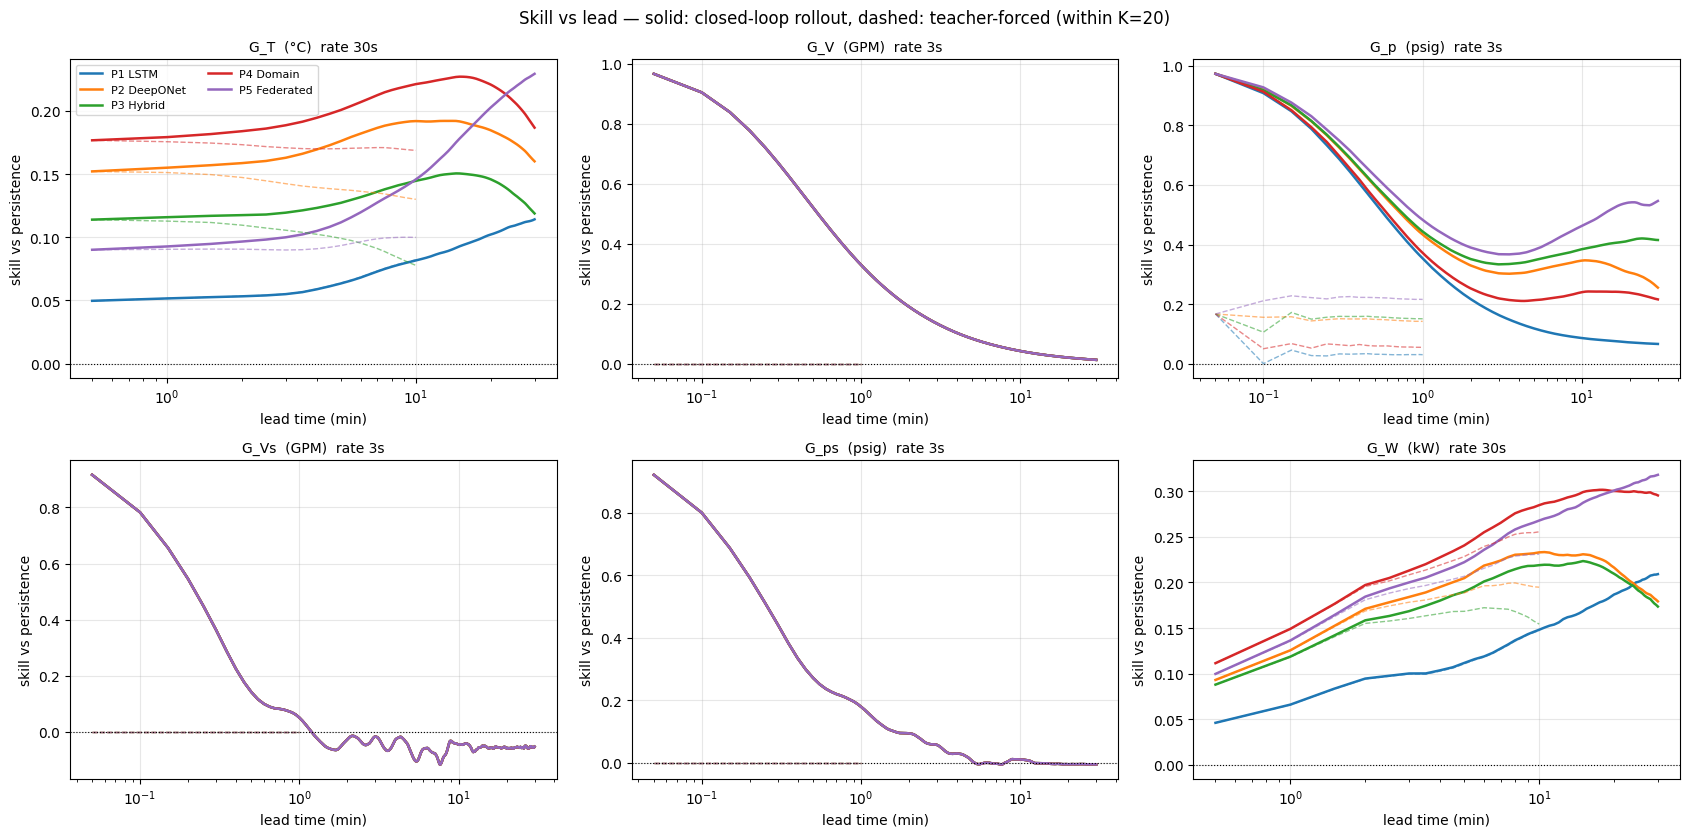

In [ ]:
# skill vs lead: teacher-forced (dashed) vs closed-loop (solid), per head
MODEL_COLOR = {pid: c for pid, c in zip(
    RUNS, plt.rcParams["axes.prop_cycle"].by_key()["color"])}

fig, axes = plt.subplots(2, 3, figsize=(17, 8.5), sharex=False)
for ax, h in zip(axes.ravel(), ALL_HEADS):
    for pid, df in RO.items():
        d = df[df["head"] == h]
        ax.plot(d["lead_s"] / 60, d["skill"], lw=1.8,
                color=MODEL_COLOR[pid], label=RUNS[pid]["label"])
    for pid, df in TF.items():
        d = df[df["head"] == h]
        ax.plot(d["lead_s"] / 60, d["skill"], lw=1.0, ls="--", alpha=0.55,
                color=MODEL_COLOR[pid])
    ax.axhline(0, color="k", lw=0.8, ls=":")
    ax.set_xscale("log")
    ax.set_title(f"{h}  ({GUNIT[h]})  rate {RATE[h]}s", fontsize=10)
    ax.set_xlabel("lead time (min)"); ax.set_ylabel("skill vs persistence")
    ax.grid(alpha=0.3)
axes.ravel()[0].legend(fontsize=8, ncol=2)
fig.suptitle("Skill vs lead: solid: closed-loop rollout, dashed: teacher-forced "
             f"(within K={KMAX['G_T']})", fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / "skill_vs_lead_rollout.png", dpi=150, bbox_inches="tight")
plt.show()

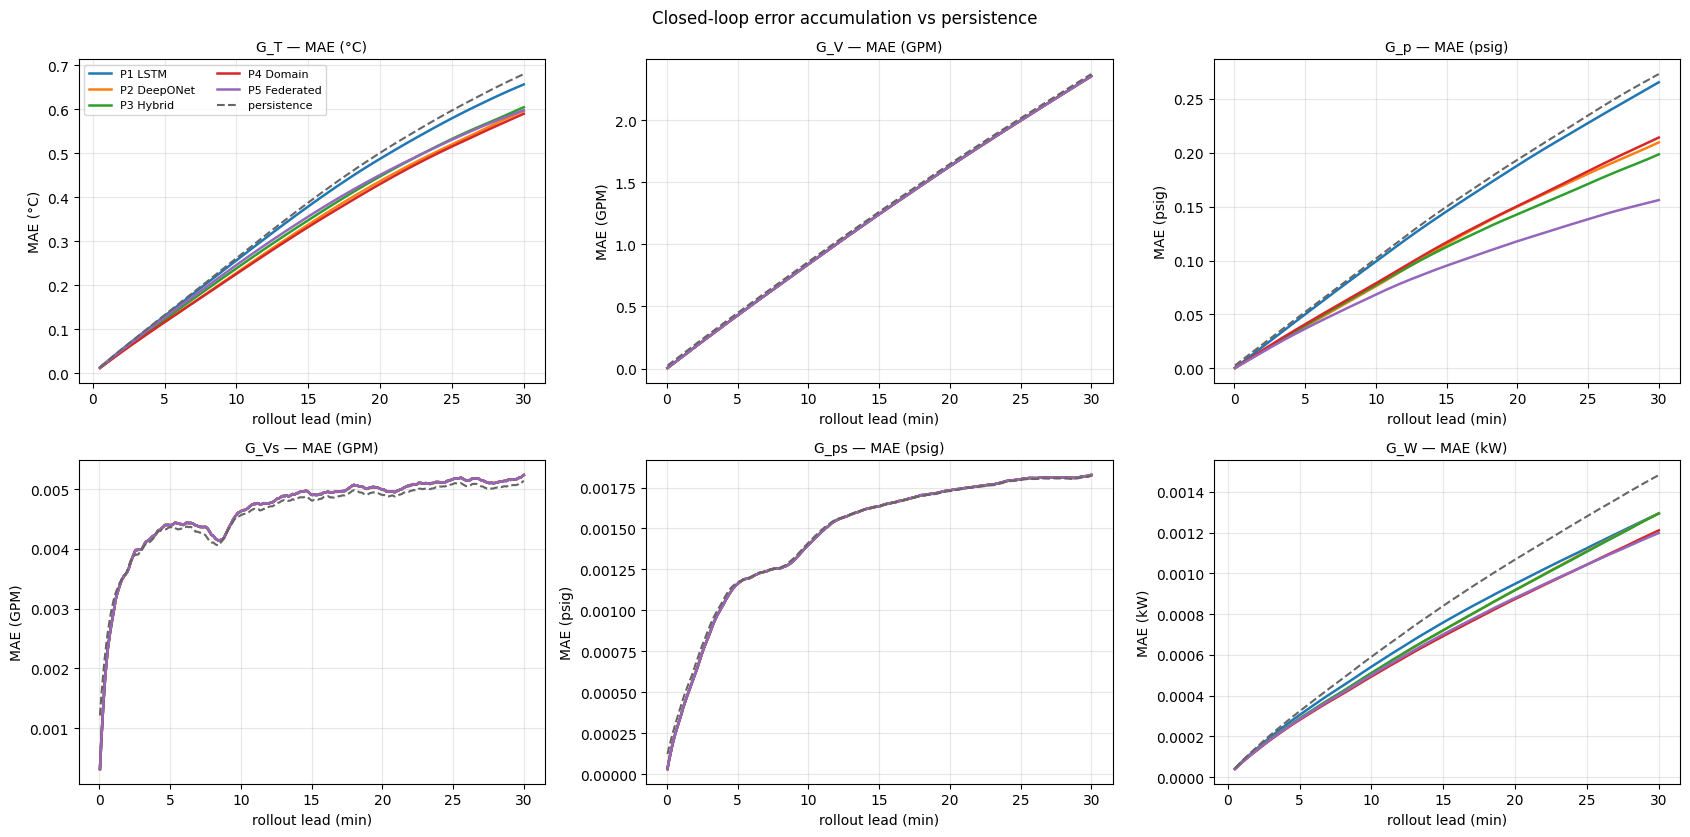

In [ ]:
#  error accumulation: model MAE vs persistence MAE across the rollout
fig, axes = plt.subplots(2, 3, figsize=(17, 8.5))
for ax, h in zip(axes.ravel(), ALL_HEADS):
    for pid, df in RO.items():
        d = df[df["head"] == h]
        ax.plot(d["lead_s"] / 60, d["mae"], lw=1.8,
                color=MODEL_COLOR[pid], label=RUNS[pid]["label"])
    d0 = RO[next(iter(RO))].query("head == @h")
    ax.plot(d0["lead_s"] / 60, d0["mae_pers"], color="0.4", lw=1.5, ls="--",
            label="persistence")
    ax.set_title(f"{h}: MAE ({GUNIT[h]})", fontsize=10)
    ax.set_xlabel("rollout lead (min)"); ax.set_ylabel(f"MAE ({GUNIT[h]})")
    ax.grid(alpha=0.3)
axes.ravel()[0].legend(fontsize=8, ncol=2)
fig.suptitle("Closed-loop error accumulation vs persistence", fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / "error_accum_rollout.png", dpi=150, bbox_inches="tight")
plt.show()

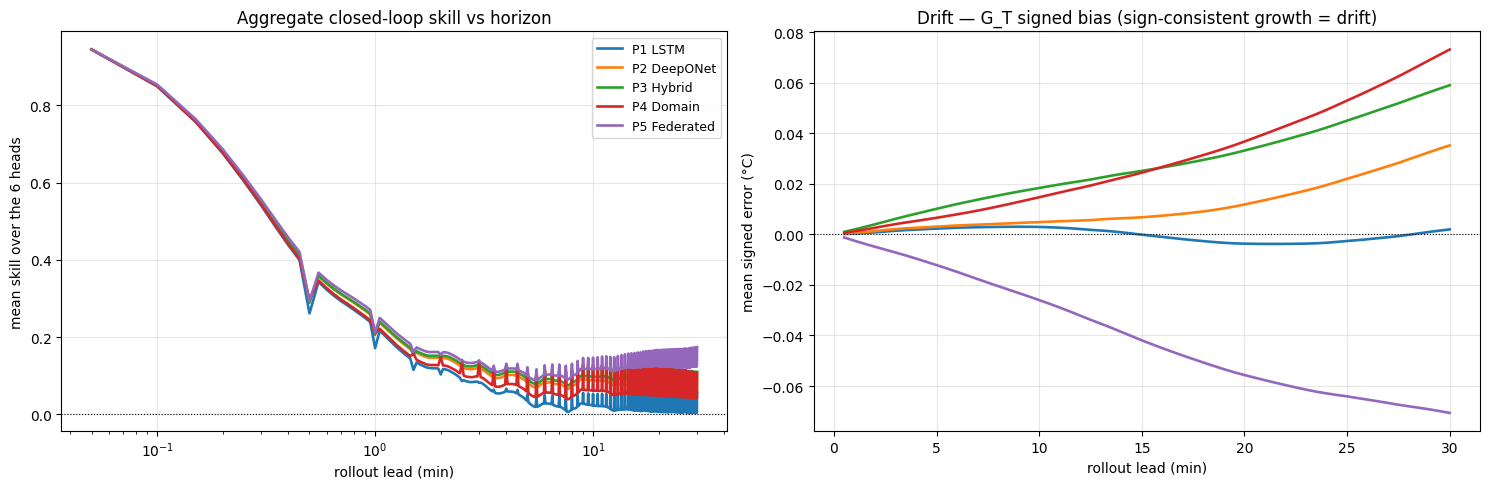

horizon_s       30      60      300     600     1200    1800
model                                                       
P1 LSTM       0.5797  0.4243  0.1561  0.0908  0.0545  0.0406
P2 DeepONet   0.5911  0.4404  0.1898  0.1380  0.1099  0.0951
P3 Hybrid     0.5904  0.4405  0.1939  0.1436  0.1206  0.1125
P4 Domain     0.5862  0.4321  0.1731  0.1179  0.0905  0.0788
P5 Federated  0.5945  0.4467  0.2021  0.1551  0.1406  0.1370


In [ ]:
# aggregate skill vs rollout horizon + drift (mean signed bias)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for pid, df in RO.items():
    g = df.groupby("lead_s")["skill"].mean()
    axes[0].plot(g.index / 60, g.values, lw=1.9,
                 color=MODEL_COLOR[pid], label=RUNS[pid]["label"])
axes[0].axhline(0, color="k", lw=0.8, ls=":")
axes[0].set_xscale("log"); axes[0].grid(alpha=0.3)
axes[0].set_xlabel("rollout lead (min)")
axes[0].set_ylabel("mean skill over the 6 heads")
axes[0].set_title("Aggregate closed-loop skill vs horizon")
axes[0].legend(fontsize=9)

for pid, df in RO.items():
    d = df[df["head"] == "G_T"]
    axes[1].plot(d["lead_s"] / 60, d["bias"], lw=1.9,
                 color=MODEL_COLOR[pid], label=RUNS[pid]["label"])
axes[1].axhline(0, color="k", lw=0.8, ls=":")
axes[1].grid(alpha=0.3)
axes[1].set_xlabel("rollout lead (min)")
axes[1].set_ylabel(f"mean signed error ({GUNIT['G_T']})")
axes[1].set_title("Drift: G_T signed bias (sign-consistent growth = drift)")
fig.tight_layout()
fig.savefig(OUT_DIR / "rollout_aggregate_and_drift.png", dpi=150, bbox_inches="tight")
plt.show()

print(SNAP.pivot(index="model", columns="horizon_s", values="mean_skill")
      .round(4).to_string())

## 7: Part C: speedup

Two things are timed:

* per forward pass across a batch-size sweep: the throughput figure;
* per rolled-out horizon: `N_STRIDES` sequential forwards, which is the
  cost that actually matters when the surrogate replaces the FMU in a loop and
  cannot be batched over time.

In [ ]:
#  inference timing (multi-rate aware)
FMU_S_PER_STRIDE = float(os.environ.get("FMU_S_PER_STRIDE", 65.43))   # s per 30 s step
BATCH_SIZES = [int(b) for b in os.environ.get(
    "BATCH_SIZES", "1,4,16,64,256,1024,2048,4096").split(",")]
N_WARMUP, N_REPEATS = 5, 50


def synth_batch(bs):
    """Random inputs with the right shapes; values do not affect timing."""
    return {b: (torch.randn(bs, H, N_IN,  device=DEVICE),
                torch.randn(bs, H, N_DYN, device=DEVICE))
            for b, (r, H) in BRANCH_SPEC.items()}


def sync():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def time_forward(model, bs, n_warmup=N_WARMUP, n_repeats=N_REPEATS):
    batch = synth_batch(bs)
    for _ in range(n_warmup):
        model(batch)
    sync()
    ts = []
    for _ in range(n_repeats):
        t0 = time.perf_counter(); model(batch); sync()
        ts.append(time.perf_counter() - t0)
    ts = np.array(ts)
    return dict(mean_ms=ts.mean() * 1e3, std_ms=ts.std() * 1e3,
                per_sample_ms=ts.mean() * 1e3 / bs)


rows = []
for pid, run in RUNS.items():
    for bs in BATCH_SIZES:
        try:
            t = time_forward(run["model"], bs)
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"  phase {pid} bs={bs}: OOM, skipping"); torch.cuda.empty_cache(); continue
            raise
        rows.append(dict(phase=pid, model=run["label"], n_params=run["n_params"],
                         batch_size=bs, t))
        print(f"phase {pid}  {run['label']:<14} bs={bs:>5}  "
              f"{t['mean_ms']:8.3f} ms  {t['per_sample_ms']:8.4f} ms/sample")
TIMING = pd.DataFrame(rows)

# One surrogate forward covers STRIDE_S seconds of plant time in the closed loop.
TIMING["fmu_s_equiv"]      = FMU_S_PER_STRIDE
TIMING["speedup_1sample"]  = FMU_S_PER_STRIDE / (TIMING["mean_ms"] / 1e3)
TIMING["speedup_batched"]  = FMU_S_PER_STRIDE / (TIMING["per_sample_ms"] / 1e3)
TIMING.to_csv(OUT_DIR / "timing.csv", index=False)
TIMING.head()

phase 1  P1 LSTM        bs=    1     4.289 ms    4.2886 ms/sample
phase 1  P1 LSTM        bs=    4     3.746 ms    0.9364 ms/sample
phase 1  P1 LSTM        bs=   16     4.996 ms    0.3123 ms/sample
phase 1  P1 LSTM        bs=   64     9.250 ms    0.1445 ms/sample
phase 1  P1 LSTM        bs=  256    22.920 ms    0.0895 ms/sample
phase 1  P1 LSTM        bs= 1024    65.714 ms    0.0642 ms/sample
phase 1  P1 LSTM        bs= 2048   127.745 ms    0.0624 ms/sample
  phase 1 bs=4096: OOM, skipping
phase 2  P2 DeepONet    bs=    1     4.410 ms    4.4096 ms/sample
phase 2  P2 DeepONet    bs=    4     4.558 ms    1.1395 ms/sample
phase 2  P2 DeepONet    bs=   16     6.592 ms    0.4120 ms/sample
phase 2  P2 DeepONet    bs=   64    13.989 ms    0.2186 ms/sample
phase 2  P2 DeepONet    bs=  256    40.288 ms    0.1574 ms/sample
phase 2  P2 DeepONet    bs= 1024   133.344 ms    0.1302 ms/sample
  phase 2 bs=2048: OOM, skipping
  phase 2 bs=4096: OOM, skipping
phase 3  P3 Hybrid      bs=    1     4.631 

,phase,model,n_params,batch_size,mean_ms,std_ms,per_sample_ms,fmu_s_equiv,speedup_1sample,speedup_batched
0,1,P1 LSTM,20785886,1,4.288583,0.742369,4.288583,65.43,15256.786547,15256.786547
1,1,P1 LSTM,20785886,4,3.745782,0.047227,0.936446,65.43,17467.647437,69870.589747
2,1,P1 LSTM,20785886,16,4.996073,0.053887,0.312255,65.43,13096.285134,209540.562141
3,1,P1 LSTM,20785886,64,9.249564,0.050847,0.144524,65.43,7073.846559,452726.179785
4,1,P1 LSTM,20785886,256,22.919645,0.089244,0.089530,65.43,2854.756320,730817.618018


In [16]:
# rollout wall clock: N_STRIDES sequential forwards (cannot batch over time)
roll_rows = []
for pid, run in RUNS.items():
    t1 = TIMING.query("phase == @pid and batch_size == 1")
    if t1.empty: continue
    ms1 = float(t1["mean_ms"].iloc[0])
    surrogate_s = ms1 * N_STRIDES / 1e3
    fmu_s       = FMU_S_PER_STRIDE * N_STRIDES
    roll_rows.append(dict(
        model=RUNS[pid]["label"], n_params=run["n_params"],
        ms_per_forward=round(ms1, 3),
        rollout_s_surrogate=round(surrogate_s, 4),
        rollout_s_fmu=round(fmu_s, 1),
        speedup=round(fmu_s / surrogate_s, 1),
        horizon_min=ROLLOUT_S / 60))
ROLL_SPEED = pd.DataFrame(roll_rows)
print(f"closed-loop cost for a {ROLLOUT_S/60:.0f} min horizon "
      f"({N_STRIDES} sequential forwards):")
print(ROLL_SPEED.to_string(index=False))
ROLL_SPEED.to_csv(OUT_DIR / "rollout_speedup.csv", index=False)

closed-loop cost for a 30 min horizon (60 sequential forwards):
       model  n_params  ms_per_forward  rollout_s_surrogate  rollout_s_fmu  speedup  horizon_min
     P1 LSTM  20785886           4.289               0.2573         3925.8  15256.8         30.0
 P2 DeepONet  55594626           4.410               0.2646         3925.8  14838.1         30.0
   P3 Hybrid  55597453           4.631               0.2779         3925.8  14127.9         30.0
   P4 Domain  55603107           4.716               0.2830         3925.8  13873.3         30.0
P5 Federated   5868638           4.066               0.2439         3925.8  16093.3         30.0


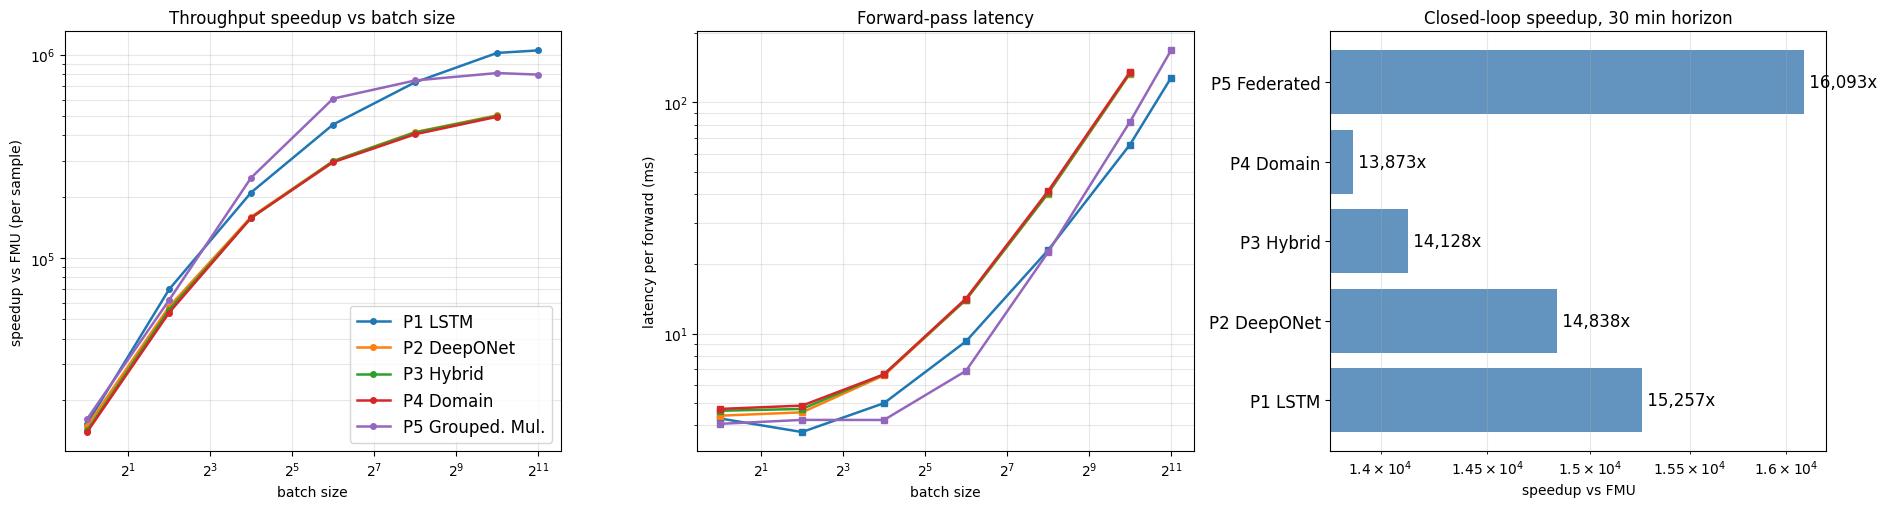

In [36]:
# 16  speedup figures (same three views as Speedup_benchmarking.ipynb)
fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))

for pid in RUNS:
    d = TIMING[TIMING["phase"] == pid].sort_values("batch_size")
    if d.empty: continue
    axes[0].plot(d["batch_size"], d["speedup_batched"], "o-", lw=1.8, ms=4,
                 label=RUNS[pid]["label"])
axes[0].set_xscale("log", base=2); axes[0].set_yscale("log")
axes[0].set_xlabel("batch size"); axes[0].set_ylabel("speedup vs FMU (per sample)")
axes[0].set_title("Throughput speedup vs batch size"); axes[0].grid(alpha=0.3, which="both")
axes[0].legend(fontsize=12)


for pid in RUNS:
    d = TIMING[TIMING["phase"] == pid].sort_values("batch_size")
    if d.empty: continue
    axes[1].plot(d["batch_size"], d["mean_ms"], "s-", lw=1.8, ms=4,
                 label=RUNS[pid]["label"])
axes[1].set_xscale("log", base=2); axes[1].set_yscale("log")
axes[1].set_xlabel("batch size"); axes[1].set_ylabel("latency per forward (ms)")
axes[1].set_title("Forward-pass latency"); axes[1].grid(alpha=0.3, which="both")

if not ROLL_SPEED.empty:
    ax = axes[2]
    y = np.arange(len(ROLL_SPEED))
    ax.barh(y, ROLL_SPEED["speedup"], color="steelblue", alpha=0.85)
    ax.set_yticks(y); ax.set_yticklabels(ROLL_SPEED["model"], fontsize=12)
    ax.set_xscale("log"); ax.set_xlabel("speedup vs FMU")
    ax.set_title(f"Closed-loop speedup, {ROLLOUT_S/60:.0f} min horizon")
    ax.grid(alpha=0.3, axis="x", which="both")
    for yi, v in zip(y, ROLL_SPEED["speedup"]):
        ax.text(v, yi, f" {v:,.0f}x", va="center", fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / "speedup.png", dpi=150, bbox_inches="tight")
plt.show()

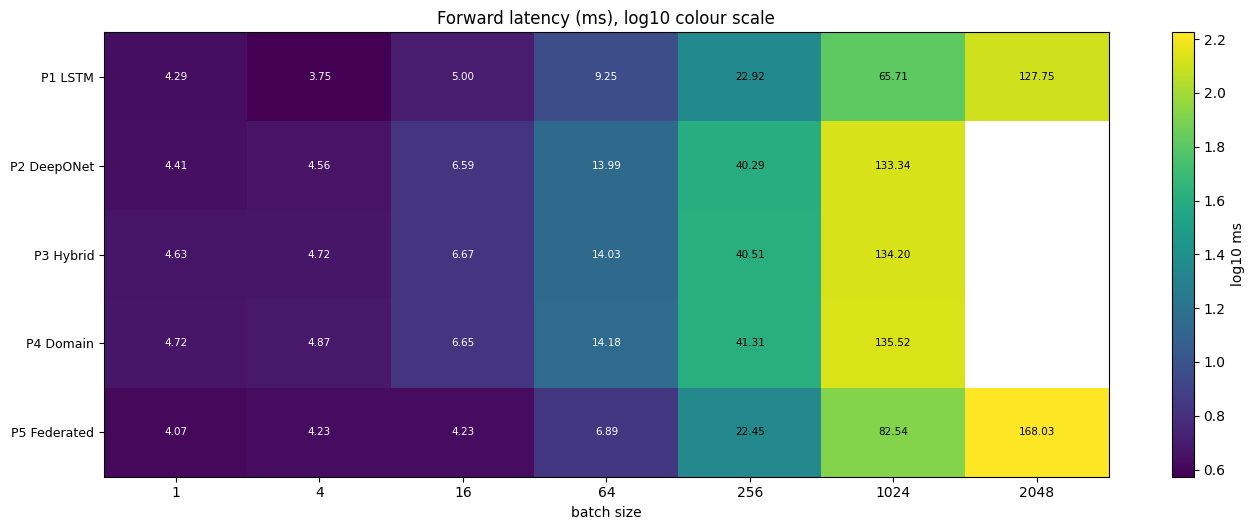

In [18]:
# latency heatmap (models x batch size), matching the earlier notebook
piv = TIMING.pivot(index="model", columns="batch_size", values="mean_ms")
fig, ax = plt.subplots(figsize=(1.4 * len(piv.columns) + 4, 0.6 * len(piv) + 2.4))
im = ax.imshow(np.log10(piv.values), aspect="auto", cmap="viridis")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index, fontsize=9)
ax.set_xlabel("batch size"); ax.set_title("Forward latency (ms), log10 colour scale")
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                    color="w" if np.log10(v) < np.nanmean(np.log10(piv.values)) else "k")
fig.colorbar(im, ax=ax, label="log10 ms")
fig.tight_layout()
fig.savefig(OUT_DIR / "latency_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8: Combined summary

In [19]:
# one table per model: accuracy in-window, accuracy rolled out, and cost
summary = []
for pid, run in RUNS.items():
    tf, ro = TF[pid], RO[pid]
    tf_short = tf[tf["lead_s"] <= 60]
    row = dict(model=run["label"], params_M=round(run["n_params"] / 1e6, 2))
    row["tf_skill"]        = round(tf["skill"].mean(), 4)
    row["tf_skill_60s"]    = round(tf_short["skill"].mean(), 4)
    row["tf_r2"]           = round(tf["r2"].mean(), 4)
    row["roll_skill"]      = round(ro["skill"].mean(), 4)
    row["roll_r2"]         = round(ro["r2"].mean(), 4)
    row["roll_beats"]      = round(ro["beats"].mean(), 3)
    end = ro[ro["lead_s"] >= ro["lead_s"].max() * 0.9]
    row[f"roll_r2_at_{int(ROLLOUT_S)}s"] = round(end["r2"].mean(), 4)
    t1 = TIMING.query("phase == @pid and batch_size == 1")
    row["ms_per_forward"] = round(float(t1["mean_ms"].iloc[0]), 3) if not t1.empty else np.nan
    rs = ROLL_SPEED[ROLL_SPEED["model"] == run["label"]]
    row["rollout_speedup"] = int(rs["speedup"].iloc[0]) if not rs.empty else np.nan
    summary.append(row)
SUMMARY = pd.DataFrame(summary)
SUMMARY.to_csv(OUT_DIR / "summary.csv", index=False)
print(f"horizon: teacher-forced <= {max(KMAX[h]*RATE[h] for h in ALL_HEADS)}s, "
      f"rollout {ROLLOUT_S}s ({ROLLOUT_S/60:.0f} min), {n_tot} sequences\n")
print(SUMMARY.to_string(index=False))
print(f"\nartifacts -> {OUT_DIR.resolve()}")

horizon: teacher-forced <= 600s, rollout 1800s (30 min), 156 sequences

       model  params_M  tf_skill  tf_skill_60s  tf_r2  roll_skill  roll_r2  roll_beats  roll_r2_at_1800s  ms_per_forward  rollout_speedup
     P1 LSTM     20.79    0.0356        0.0112 0.8757      0.0406   0.3275       0.732            0.1549           4.289            15256
 P2 DeepONet     55.59    0.0778        0.0415 0.8757      0.0951   0.3284       0.731            0.1568           4.410            14838
   P3 Hybrid     55.60    0.0680        0.0417 0.8757      0.1125   0.3288       0.729            0.1581           4.631            14127
   P4 Domain     55.60    0.0759        0.0225 0.8757      0.0788   0.3282       0.733            0.1564           4.716            13873
P5 Federated      5.87    0.0854        0.0566 0.8756      0.1370   0.3292       0.731            0.1593           4.066            16093

artifacts -> /lustre/orion/gen053/scratch/yishak_tadele/surrogate-uq-evals/surrogate_models/summit-

In [20]:
# per-head rollout skill at the final horizon (which channels survive?)
final = (RO_ALL[RO_ALL["lead_s"] >= RO_ALL["lead_s"].max() * 0.9]
         .groupby(["model", "head"])[["r2", "r2_pers", "skill", "beats"]].mean().round(4))
print(f"per-head performance in the last 10% of the {ROLLOUT_S}s rollout:")
print(final.to_string())
final.to_csv(OUT_DIR / "rollout_final_per_head.csv")

per-head performance in the last 10% of the 1800s rollout:
                       r2  r2_pers   skill   beats
model        head                                 
P1 LSTM      G_T   0.9546   0.9525  0.1128  0.9664
             G_V   0.4952   0.4884  0.0134  1.0000
             G_Vs -0.9757  -0.8757 -0.0557  0.3044
             G_W   0.9932   0.9913  0.2075  0.9950
             G_p   0.9647   0.9622  0.0665  1.0000
             G_ps -0.0526  -0.0470 -0.0055  0.3621
P2 DeepONet  G_T   0.9612   0.9525  0.1649  0.8997
             G_V   0.4952   0.4884  0.0134  1.0000
             G_Vs -0.9757  -0.8757 -0.0557  0.3044
             G_W   0.9931   0.9913  0.1842  0.9094
             G_p   0.9722   0.9622  0.2654  1.0000
             G_ps -0.0526  -0.0470 -0.0055  0.3621
P3 Hybrid    G_T   0.9587   0.9525  0.1236  0.8202
             G_V   0.4952   0.4884  0.0134  1.0000
             G_Vs -0.9757  -0.8757 -0.0557  0.3044
             G_W   0.9930   0.9913  0.1791  0.8883
             G_p   0.97